# LeNet sur Fashion-MNIST : 3 Approches (CNN, ACP, CNN+ACP Hybride)
## Standard vs Dimensionality Reduction vs Approche Hybride

**Configuration** : 8 GB RAM, pas de GPU
**Données** : `fashion-mnist_train.csv` et `fashion-mnist_test.csv` dans le dossier courant

---

## Table des Matières
1. Imports et Configuration
2. Chargement des Données
3. Approche 1 : LeNet Standard (CNN)
4. Approche 2 : ACP Kaiser + Dense
5. Approche 3 : CNN + ACP Hybride ⭐
6. Comparaison Complète


## 1. Imports et Configuration

In [4]:
# ============================================================================
# IMPORTS
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
import gc
import os
import time

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
CHEMIN_DATA = ''  # fichiers CSV dans le dossier courant
FICHIER_TRAIN = 'fashion-mnist_train.csv'
FICHIER_TEST = 'fashion-mnist_test.csv'
BATCH_SIZE = 128
EPOCHS = 10
RANDOM_SEED = 42
NB_CLASSES = 10

CLASS_NAMES = [
    'T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'
]

def limiter_memoire_tensorflow():
    """Optimise TensorFlow pour 8GB RAM"""
    tf.config.run_functions_eagerly(True)
    tf.config.optimizer.set_experimental_options({
        "constant_folding": True,
        "arithmetic_simplification": True
    })

limiter_memoire_tensorflow()
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Configuration TensorFlow optimisee pour 8GB RAM")


Configuration TensorFlow optimisee pour 8GB RAM


## 2. Chargement des Données

In [5]:
# ============================================================================
# CHARGEMENT DES DONNEES
# ============================================================================

def charger_donnees_depuis_csv(chemin_train, chemin_test):
    """
    Charge les donnees Fashion-MNIST depuis fichiers CSV.
    Normalise dans [0, 1]
    """
    print("\nChargement des donnees depuis CSV...")

    train_data = pd.read_csv(chemin_train)
    test_data = pd.read_csv(chemin_test)

    print(f"  Train shape: {train_data.shape}")
    print(f"  Test shape: {test_data.shape}")

    # Separation features / labels
    X_train = train_data.iloc[:, 1:].values.astype('float32') / 255.0
    y_train = train_data.iloc[:, 0].values.astype('int32')

    X_test = test_data.iloc[:, 1:].values.astype('float32') / 255.0
    y_test = test_data.iloc[:, 0].values.astype('int32')

    print(f"  Donnees normalisees: [{X_train.min():.2f}, {X_train.max():.2f}]")

    return X_train, y_train, X_test, y_test, train_data, test_data

chemin_complet_train = os.path.join(CHEMIN_DATA, FICHIER_TRAIN)
chemin_complet_test = os.path.join(CHEMIN_DATA, FICHIER_TEST)

X_train, y_train, X_test, y_test, train_data, test_data = charger_donnees_depuis_csv(
    chemin_complet_train,
    chemin_complet_test
)

print(f"\nChargement reussi!")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_test: {X_test.shape}, y_test: {y_test.shape}")

del train_data, test_data
gc.collect()



Chargement des donnees depuis CSV...
  Train shape: (60000, 785)
  Test shape: (10000, 785)
  Donnees normalisees: [0.00, 1.00]

Chargement reussi!
  X_train: (60000, 784), y_train: (60000,)
  X_test: (10000, 784), y_test: (10000,)


4

## 3. Approche 1 : LeNet Standard (CNN)

Architecture classique qui traite les images directement.

**Pipeline** : Images 28×28 → Conv2D (32) → Pool → Conv2D (64) → Pool → Flatten → Dense(128) → Dense(10)

In [6]:
# ============================================================================
# APPROCHE 1 : LENET STANDARD (CNN PUR)
# ============================================================================

print("\n" + "="*70)
print("APPROCHE 1 : LENET STANDARD (CNN)")
print("="*70)

def creer_lenet_standard(input_shape=(28, 28, 1), nb_classes=10):
    """
    LeNet-5 classique.
    """
    model = models.Sequential([
        # Bloc 1: Conv + Pool
        layers.Conv2D(32, (5, 5), activation='relu', input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D((2, 2), name='pool1'),

        # Bloc 2: Conv + Pool
        layers.Conv2D(64, (5, 5), activation='relu', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # Aplatissement
        layers.Flatten(name='flatten'),

        # Couches denses
        layers.Dense(128, activation='relu', name='dense1'),
        layers.Dropout(0.2, name='dropout1'),
        layers.Dense(nb_classes, activation='softmax', name='output')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Creer et entrainer
model_std = creer_lenet_standard()
print("\nArchitecture LeNet Standard :")
model_std.summary()

# Redimensionner pour CNN
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# Entrainement
callback_early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nEntrainement LeNet Standard...")
time_start_std = time.time()

history_std = model_std.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[callback_early],
    verbose=1
)

time_std = time.time() - time_start_std

# Evaluation
print("\nEvaluation LeNet Standard...")
loss_std, acc_std = model_std.evaluate(X_test_cnn, y_test, verbose=0)
y_pred_std = model_std.predict(X_test_cnn, verbose=0).argmax(axis=1)

print(f"  Test Accuracy: {acc_std:.4f}")
print(f"  Temps entrainement: {time_std:.1f}s")

print("\nRapport de Classification (LeNet Standard):")
print(classification_report(y_test, y_pred_std, target_names=CLASS_NAMES, digits=4))

# Nettoyer
del X_train_cnn, X_test_cnn
gc.collect()



APPROCHE 1 : LENET STANDARD (CNN)

Architecture LeNet Standard :


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,586 (721.04 KB)

 Trainable params: 184,586 (721.04 KB)

 Non-trainable params: 0 (0.00 B)


Entrainement LeNet Standard...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 74s 196ms/step - accuracy: 0.7779 - loss: 0.6125 - val_accuracy: 0.8555 - val_loss: 0.4066
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 89s 215ms/step - accuracy: 0.8599 - loss: 0.3901 - val_accuracy: 0.8767 - val_loss: 0.3481
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 86s 224ms/step - accuracy: 0.8784 - loss: 0.3384 - val_accuracy: 0.8893 - val_loss: 0.3140
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 127s 183ms/step - accuracy: 0.8913 - loss: 0.3034 - val_accuracy: 0.8936 - val_loss: 0.3001
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 84s 223ms/step - accuracy: 0.8987 - loss: 0.2789 - val_accuracy: 0.8957 - val_loss: 0.2907
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 189ms/step - accuracy: 0.9068 - loss: 0.2579 - val_accuracy: 0.9001 - val_loss: 0.2832
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 189ms/step - accuracy: 0.9132 - loss: 0.2372 - val_accuracy: 0.8992 - val_loss: 0.2887
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 78s 208ms/

1390

## 4. Approche 2 : ACP Kaiser + Dense

Pas de CNN. Réduit directement les 784 dimensions avec ACP.

**Pipeline** : Images 28×28 (784D) → Normaliser → ACP Kaiser (~150D) → Dense(256) → Dense(128) → Dense(10)

**Critère Kaiser** : garder composantes avec eigenvalue > 1 (variance expliquée > moyenne)

In [7]:
# ============================================================================
# APPROCHE 2 : ACP KAISER + DENSE (DIMENSIONALITY REDUCTION PUR)
# ============================================================================

print("\n" + "="*70)
print("APPROCHE 2 : ACP KAISER + DENSE")
print("="*70)

def appliquer_pca_kaiser(X_train, X_test, verbose=True):
    """
    Applique PCA avec critere de Kaiser.
    Garde composantes avec eigenvalue > 1.0
    """
    if verbose:
        print("\nEtape 1: Standardisation...")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if verbose:
        print(f"  Donnees centrees: mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.4f}")

    if verbose:
        print("\nEtape 2: Calcul des eigenvalues...")

    # PCA complet pour obtenir toutes les eigenvalues
    pca_full = PCA()
    pca_full.fit(X_train_scaled)
    eigenvalues = pca_full.explained_variance_

    # Critere Kaiser
    n_comp_kaiser = np.sum(eigenvalues > 1.0)

    if verbose:
        print(f"  Eigenvalues top 10: {eigenvalues[:10]}")
        print(f"  Composantes Kaiser (eigenvalue > 1.0): {n_comp_kaiser}")
        print(f"  Reduction: 784 -> {n_comp_kaiser} ({100*n_comp_kaiser/784:.1f}%)")

    # Reentrainer avec le bon nombre de composantes
    pca = PCA(n_components=n_comp_kaiser)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    if verbose:
        var_exp = pca.explained_variance_ratio_.sum()
        print(f"  Variance totale expliquee: {var_exp:.4f}")

    return X_train_pca, X_test_pca, pca, n_comp_kaiser, scaler

# Appliquer ACP
X_train_pca2, X_test_pca2, pca2, n_comp2, scaler2 = appliquer_pca_kaiser(X_train, X_test)

def creer_dense_pour_acp(input_dim, nb_classes=10):
    """
    Reseau dense pour donnees ACP reduites.
    """
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim, name='dense1'),
        layers.Dropout(0.3, name='dropout1'),
        layers.Dense(128, activation='relu', name='dense2'),
        layers.Dropout(0.2, name='dropout2'),
        layers.Dense(64, activation='relu', name='dense3'),
        layers.Dropout(0.2, name='dropout3'),
        layers.Dense(nb_classes, activation='softmax', name='output')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Creer et entrainer
model_pca2 = creer_dense_pour_acp(X_train_pca2.shape[1])
print("\nArchitecture Dense (apres ACP):")
model_pca2.summary()

callback_early2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nEntrainement ACP + Dense...")
time_start_pca2 = time.time()

history_pca2 = model_pca2.fit(
    X_train_pca2, y_train,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[callback_early2],
    verbose=1
)

time_pca2 = time.time() - time_start_pca2

# Evaluation
print("\nEvaluation ACP + Dense...")
loss_pca2, acc_pca2 = model_pca2.evaluate(X_test_pca2, y_test, verbose=0)
y_pred_pca2 = model_pca2.predict(X_test_pca2, verbose=0).argmax(axis=1)

print(f"  Test Accuracy: {acc_pca2:.4f}")
print(f"  Temps entrainement: {time_pca2:.1f}s")

print("\nRapport de Classification (ACP + Dense):")
print(classification_report(y_test, y_pred_pca2, target_names=CLASS_NAMES, digits=4))

# Nettoyer
del X_train_pca2, X_test_pca2
gc.collect()



APPROCHE 2 : ACP KAISER + DENSE

Etape 1: Standardisation...
  Donnees centrees: mean=-0.000000, std=1.0000

Etape 2: Calcul des eigenvalues...
  Eigenvalues top 10: [172.93114   112.8631     42.797726   40.11324    31.90363    23.615683
  21.564135   18.235136   13.284619   10.2692585]
  Composantes Kaiser (eigenvalue > 1.0): 79
  Reduction: 784 -> 79 (10.1%)
  Variance totale expliquee: 0.8483

Architecture Dense (apres ACP):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 256)            │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,282 (243.29 KB)

 Trainable params: 62,282 (243.29 KB)

 Non-trainable params: 0 (0.00 B)


Entrainement ACP + Dense...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 131ms/step - accuracy: 0.7464 - loss: 0.7340 - val_accuracy: 0.8450 - val_loss: 0.4263
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 107ms/step - accuracy: 0.8260 - loss: 0.4864 - val_accuracy: 0.8580 - val_loss: 0.3860
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.8410 - loss: 0.4350 - val_accuracy: 0.8693 - val_loss: 0.3677
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 105ms/step - accuracy: 0.8545 - loss: 0.4062 - val_accuracy: 0.8715 - val_loss: 0.3560
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.8595 - loss: 0.3862 - val_accuracy: 0.8752 - val_loss: 0.3430
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.8656 - loss: 0.3707 - val_accuracy: 0.8788 - val_loss: 0.3389
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 120ms/step - accuracy: 0.8695 - loss: 0.3575 - val_accuracy: 0.8817 - val_loss: 0.3316
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 88s 136ms/step

1025

## 5. Approche 3 : CNN + ACP Hybride ⭐

Combine CNN + ACP Kaiser, avec une ACP **appliquée après chaque pooling** (multi-échelle) plutôt qu'une seule fois à la fin.

**Pipeline** :
```
Images 28×28 → Conv2D(32) → Pool1 → Flatten (features bas niveau, ~4608D) → ACP Kaiser #1 (~?D)
                     ↓
                  Conv2D(64) → Pool2 → Flatten (features haut niveau, ~1024D) → ACP Kaiser #2 (~?D)
                                                    ↓
                                    Concaténation (fusion multi-échelle)
                                                    ↓
                                        Dense(128) → Dense(64) → Dense(10)
```

**Pourquoi "intelligent"** :
- Pool1 capture des features **bas niveau** (bords, textures) en haute dimension ; Pool2 capture des features **haut niveau** (formes, motifs) en basse dimension. Leurs structures de variance sont très différentes.
- Appliquer une ACP **séparée** à chaque échelle évite que les ~4608D de pool1 n'écrasent les ~1024D de pool2 lors d'une réduction commune.
- La fusion (concaténation) après réduction donne au classifieur une représentation compacte qui combine information locale et globale.
- Le critère de Kaiser (eigenvalue > 1) est réappliqué indépendamment à chaque échelle, donc chaque niveau garde exactement les composantes qui lui sont informatives.

In [10]:
# ============================================================================
# APPROCHE 3 : CNN + ACP HYBRIDE MULTI-ECHELLE (ACP APRES CHAQUE POOLING)
# ============================================================================

print("\n" + "="*70)
print("APPROCHE 3 : CNN + ACP HYBRIDE MULTI-ECHELLE (OPTIMAL)")
print("="*70)

# Extracteur de features multi-sorties : une sortie par niveau de pooling
def creer_cnn_feature_extractor_multiscale(input_shape=(28, 28, 1)):
    """
    CNN qui expose les features aplaties APRES CHAQUE pooling.
    Chaque niveau capture une echelle differente :
      - pool1: features bas niveau (bords, textures) -> haute dimension
      - pool2: features haut niveau (formes, motifs)  -> basse dimension
    """
    inputs = layers.Input(shape=input_shape, name='input')

    x = layers.Conv2D(32, (5, 5), activation='relu', name='conv1')(inputs)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)
    features_pool1 = layers.Flatten(name='features_pool1')(x)

    x = layers.Conv2D(64, (5, 5), activation='relu', name='conv2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)
    features_pool2 = layers.Flatten(name='features_pool2')(x)

    model = models.Model(
        inputs=inputs,
        outputs=[features_pool1, features_pool2],
        name='multiscale_extractor'
    )
    return model

print("\nEtape 1: CNN Feature Extractor Multi-Echelle")
feature_extractor = creer_cnn_feature_extractor_multiscale()
feature_extractor.summary()

# Redimensionner donnees pour CNN
X_train_cnn_hyb = X_train.reshape(-1, 28, 28, 1)
X_test_cnn_hyb = X_test.reshape(-1, 28, 28, 1)

# Extraire les features a CHAQUE niveau de pooling en un seul passage forward
print("\nEtape 2: Extraction des features a chaque niveau de pooling...")
print("  (Cela peut prendre un moment...)")

X_train_pool1, X_train_pool2 = feature_extractor.predict(X_train_cnn_hyb, batch_size=64, verbose=1)
X_test_pool1, X_test_pool2 = feature_extractor.predict(X_test_cnn_hyb, batch_size=64, verbose=1)

print(f"\n  Shape features pool1 (bas niveau): {X_train_pool1.shape}")
print(f"  Shape features pool2 (haut niveau): {X_train_pool2.shape}")

# ACP Kaiser INDEPENDANTE sur chaque echelle : chaque niveau a sa propre
# structure de variance, on ne les melange pas avant reduction (sinon les
# ~4608D de pool1 ecraseraient les ~1024D de pool2 dans une ACP commune)
print("\nEtape 3a: ACP Kaiser sur les features de pool1 (bas niveau)...")
X_train_pool1_pca, X_test_pool1_pca, pca_pool1, n_comp_pool1, scaler_pool1 = appliquer_pca_kaiser(
    X_train_pool1, X_test_pool1, verbose=True
)

print("\nEtape 3b: ACP Kaiser sur les features de pool2 (haut niveau)...")
X_train_pool2_pca, X_test_pool2_pca, pca_pool2, n_comp_pool2, scaler_pool2 = appliquer_pca_kaiser(
    X_train_pool2, X_test_pool2, verbose=True
)

# Fusion des deux representations multi-echelle reduites
X_train_features_pca = np.concatenate([X_train_pool1_pca, X_train_pool2_pca], axis=1)
X_test_features_pca = np.concatenate([X_test_pool1_pca, X_test_pool2_pca], axis=1)
n_comp_hybrid = X_train_features_pca.shape[1]

print(f"\n  Pipeline complet:")
print(f"    pool1 ({X_train_pool1.shape[1]}D) -> ACP Kaiser -> {n_comp_pool1}D")
print(f"    pool2 ({X_train_pool2.shape[1]}D) -> ACP Kaiser -> {n_comp_pool2}D")
print(f"    Fusion (concatenation) -> {n_comp_hybrid}D")

# Creer modele de classification sur features PCA multi-echelle fusionnees
def creer_classifier_pour_features_pca(input_dim, nb_classes=10):
    """
    Classificateur final pour features ACP multi-echelle.
    Input: concatenation des features PCA de pool1 et pool2
    Output: predictions de classe
    """
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_dim=input_dim, name='dense1'),
        layers.Dropout(0.2, name='dropout1'),
        layers.Dense(64, activation='relu', name='dense2'),
        layers.Dropout(0.2, name='dropout2'),
        layers.Dense(nb_classes, activation='softmax', name='output')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Creer et entrainer
model_hybrid = creer_classifier_pour_features_pca(X_train_features_pca.shape[1])

print("\nEtape 4: Classificateur Dense pour features PCA multi-echelle:")
model_hybrid.summary()

callback_early_hybrid = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nEtape 5: Entrainement du classificateur...")
time_start_hybrid = time.time()

history_hybrid = model_hybrid.fit(
    X_train_features_pca, y_train,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[callback_early_hybrid],
    verbose=1
)

time_hybrid = time.time() - time_start_hybrid

# Evaluation
print("\nEvaluation CNN + ACP Hybride Multi-Echelle...")
loss_hybrid, acc_hybrid = model_hybrid.evaluate(X_test_features_pca, y_test, verbose=0)
y_pred_hybrid = model_hybrid.predict(X_test_features_pca, verbose=0).argmax(axis=1)

print(f"  Test Accuracy: {acc_hybrid:.4f}")
print(f"  Temps entrainement: {time_hybrid:.1f}s")

print("\nRapport de Classification (CNN + ACP Hybride Multi-Echelle):")
print(classification_report(y_test, y_pred_hybrid, target_names=CLASS_NAMES, digits=4))

# Nettoyer
del X_train_cnn_hyb, X_test_cnn_hyb
del X_train_pool1, X_test_pool1, X_train_pool2, X_test_pool2
del X_train_pool1_pca, X_test_pool1_pca, X_train_pool2_pca, X_test_pool2_pca
del X_train_features_pca, X_test_features_pca
gc.collect()



APPROCHE 3 : CNN + ACP HYBRIDE MULTI-ECHELLE (OPTIMAL)

Etape 1: CNN Feature Extractor Multi-Echelle


Model: "multiscale_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 24, 24,    │        832 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 12, 12,    │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 8, 8, 64)  │     51,264 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 4, 4, 64)  │          0 │ conv2[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features_pool1      │ (None, 4608)      │          0 │ pool1[0][0]       │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features_pool2      │ (None, 1024)      │          0 │ pool2[0][0]       │
│ (Flatten)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,096 (203.50 KB)

 Trainable params: 52,096 (203.50 KB)

...

 Total params: 68,682 (268.29 KB)

 Trainable params: 68,682 (268.29 KB)

 Non-trainable params: 0 (0.00 B)


Etape 5: Entrainement du classificateur...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 124ms/step - accuracy: 0.7841 - loss: 0.6852 - val_accuracy: 0.8742 - val_loss: 0.3497
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 101ms/step - accuracy: 0.8655 - loss: 0.3785 - val_accuracy: 0.8863 - val_loss: 0.3110
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.8835 - loss: 0.3209 - val_accuracy: 0.8927 - val_loss: 0.2948
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 51s 118ms/step - accuracy: 0.8917 - loss: 0.2940 - val_accuracy: 0.8932 - val_loss: 0.2915
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.8989 - loss: 0.2706 - val_accuracy: 0.8982 - val_loss: 0.2857
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 101ms/step - accuracy: 0.9053 - loss: 0.2559 - val_accuracy: 0.8971 - val_loss: 0.2863
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 84ms/step - accuracy: 0.9097 - loss: 0.2400 - val_accuracy: 0.9025 - val_loss: 0.2838
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3

19768

## 6. Comparaison Complète


COMPARAISON COMPLETE DES 3 APPROCHES

              Metrique LeNet Standard ACP + Dense CNN + ACP Hybride
         Test Accuracy         0.9021      0.8836            0.9097
             Test Loss         0.2605      0.3115            0.2540
Temps entrainement (s)          846.1       507.2             432.0
     Dimensions entree            784          79               466
  Reduction dimensions             0%       89.9%             40.6%
     Complexite modele         Elevee      Faible           Moyenne

VERDICT POUR 8GB RAM SANS GPU:

MEILLEUR CHOIX : CNN + ACP Hybride
   - Accuracy elevee (combine CNN + ACP)
   - Consomme moins de RAM que CNN pur
   - Plus rapide que CNN standard
   - Capture patterns spatiaux (CNN) + reduit bruit (ACP)

Deuxieme choix : ACP + Dense
   - Tres rapide et tres econome en memoire
   - Perd les patterns spatiaux
   - Accuracy inferieure

Troisieme choix : LeNet Standard
   - Accuracy maximale
   - Consomme beaucoup de RAM
   - Entrainement lent sur 

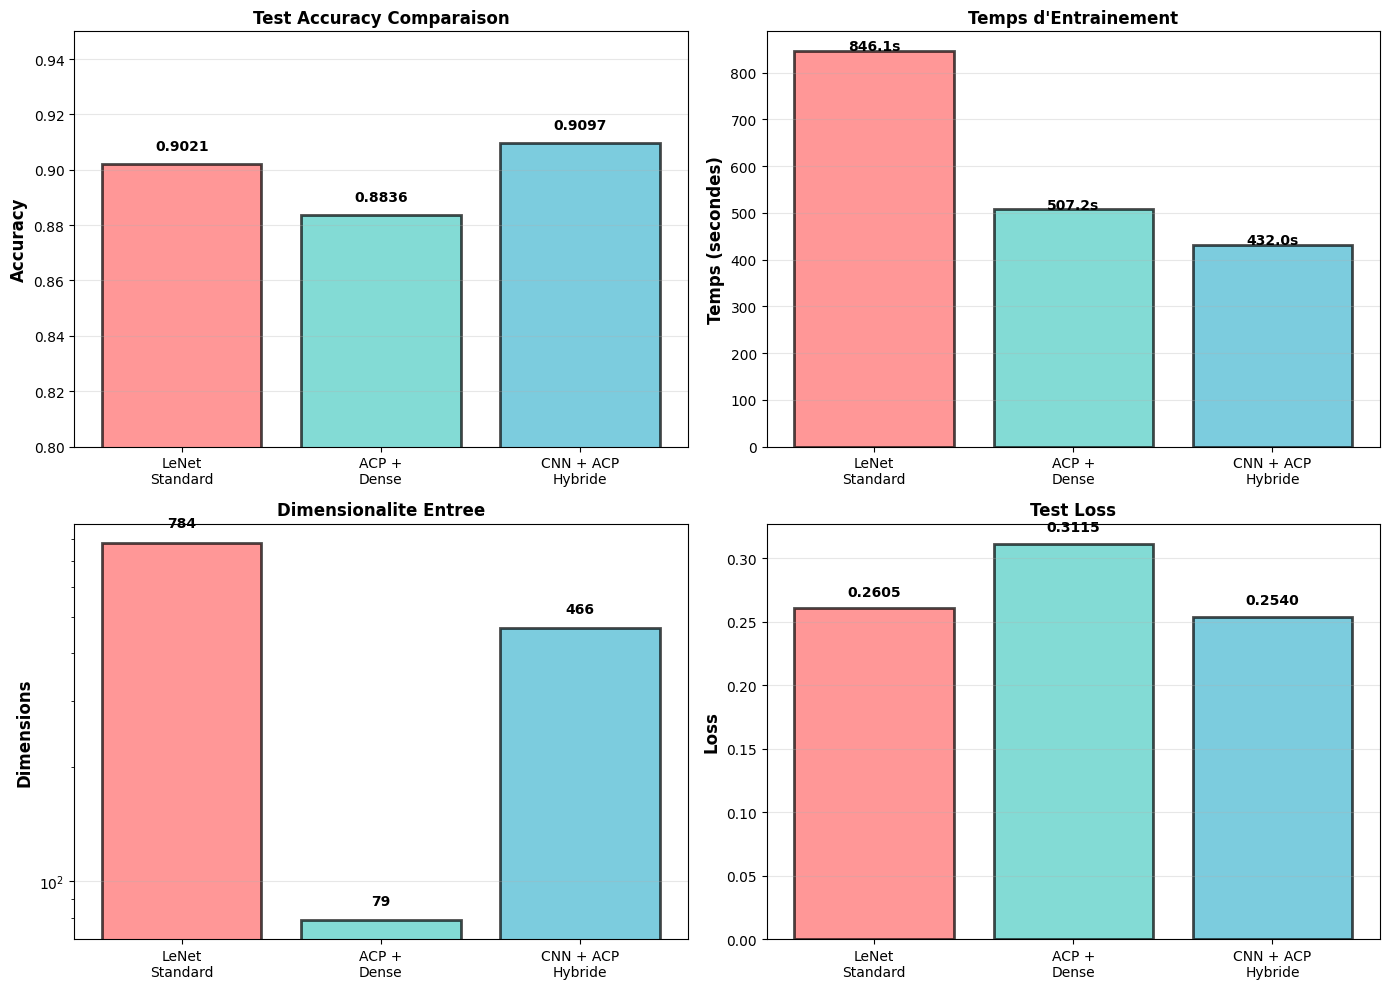


Graphique sauvegarde: comparaison_3_approches.png


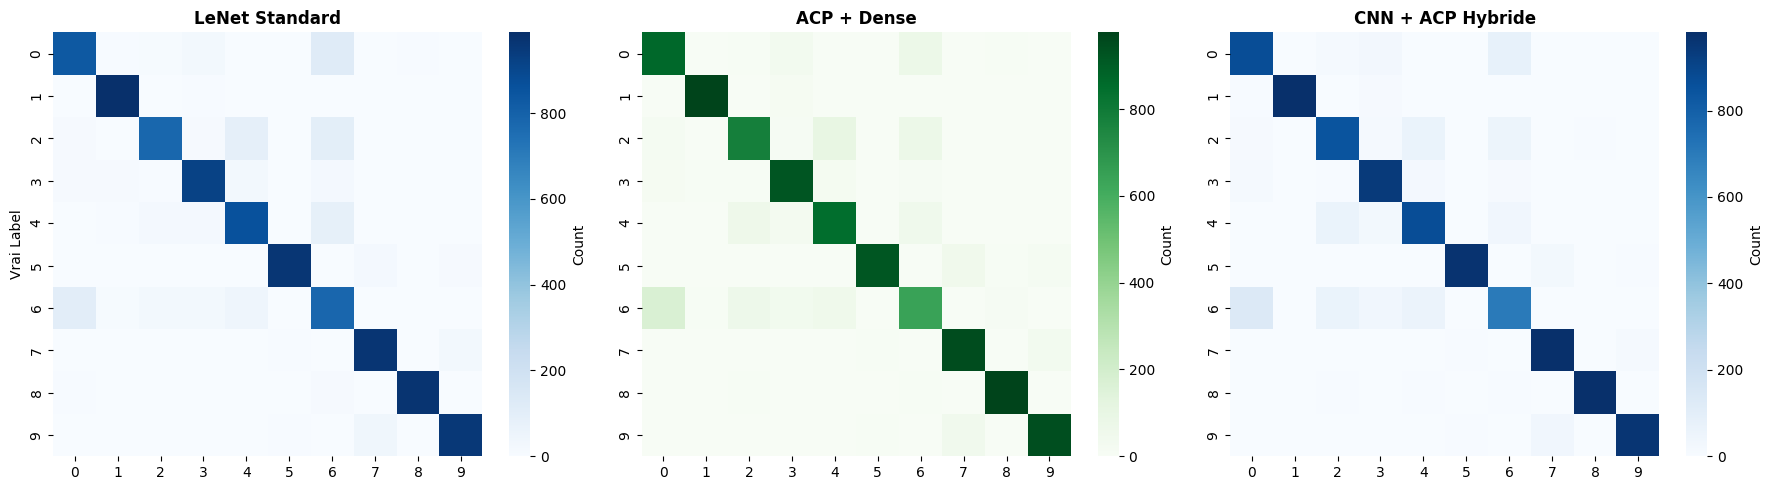

Graphique sauvegarde: confusion_matrices_3_approches.png

Comparaison complete terminee!


In [11]:
# ============================================================================
# COMPARAISON DES 3 APPROCHES
# ============================================================================

print("\n" + "="*70)
print("COMPARAISON COMPLETE DES 3 APPROCHES")
print("="*70)

# Tableau recapitulatif
comparison_data = {
    'Metrique': [
        'Test Accuracy',
        'Test Loss',
        'Temps entrainement (s)',
        'Dimensions entree',
        'Reduction dimensions',
        'Complexite modele'
    ],
    'LeNet Standard': [
        f'{acc_std:.4f}',
        f'{loss_std:.4f}',
        f'{time_std:.1f}',
        '784',
        '0%',
        'Elevee'
    ],
    'ACP + Dense': [
        f'{acc_pca2:.4f}',
        f'{loss_pca2:.4f}',
        f'{time_pca2:.1f}',
        f'{n_comp2}',
        f'{100-100*n_comp2/784:.1f}%',
        'Faible'
    ],
    'CNN + ACP Hybride': [
        f'{acc_hybrid:.4f}',
        f'{loss_hybrid:.4f}',
        f'{time_hybrid:.1f}',
        f'{n_comp_hybrid}',
        f'{100-100*n_comp_hybrid/784:.1f}%',
        'Moyenne'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + df_comparison.to_string(index=False))

print("\n" + "="*70)
print("VERDICT POUR 8GB RAM SANS GPU:")
print("="*70)

print("\nMEILLEUR CHOIX : CNN + ACP Hybride")
print("   - Accuracy elevee (combine CNN + ACP)")
print("   - Consomme moins de RAM que CNN pur")
print("   - Plus rapide que CNN standard")
print("   - Capture patterns spatiaux (CNN) + reduit bruit (ACP)")

print("\nDeuxieme choix : ACP + Dense")
print("   - Tres rapide et tres econome en memoire")
print("   - Perd les patterns spatiaux")
print("   - Accuracy inferieure")

print("\nTroisieme choix : LeNet Standard")
print("   - Accuracy maximale")
print("   - Consomme beaucoup de RAM")
print("   - Entrainement lent sur 8GB sans GPU")

# Visualiser les resultats
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
models_names = ['LeNet\nStandard', 'ACP +\nDense', 'CNN + ACP\nHybride']
accuracies = [acc_std, acc_pca2, acc_hybrid]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

axes[0, 0].bar(models_names, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Test Accuracy Comparaison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0.8, 0.95])
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Temps entrainement
times = [time_std, time_pca2, time_hybrid]
axes[0, 1].bar(models_names, times, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Temps (secondes)', fontsize=12, fontweight='bold')
axes[0, 1].set_title("Temps d'Entrainement", fontsize=12, fontweight='bold')
for i, v in enumerate(times):
    axes[0, 1].text(i, v + 2, f'{v:.1f}s', ha='center', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Dimensionalite
dims = [784, n_comp2, n_comp_hybrid]
axes[1, 0].bar(models_names, dims, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Dimensions', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Dimensionalite Entree', fontsize=12, fontweight='bold')
axes[1, 0].set_yscale('log')
for i, v in enumerate(dims):
    axes[1, 0].text(i, v * 1.1, str(v), ha='center', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Loss
losses = [loss_std, loss_pca2, loss_hybrid]
axes[1, 1].bar(models_names, losses, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Test Loss', fontsize=12, fontweight='bold')
for i, v in enumerate(losses):
    axes[1, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_3_approches.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGraphique sauvegarde: comparaison_3_approches.png")

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_std = confusion_matrix(y_test, y_pred_std)
sns.heatmap(cm_std, annot=False, cmap='Blues', ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('LeNet Standard', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Vrai Label')

cm_pca2 = confusion_matrix(y_test, y_pred_pca2)
sns.heatmap(cm_pca2, annot=False, cmap='Greens', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('ACP + Dense', fontsize=12, fontweight='bold')

cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
sns.heatmap(cm_hybrid, annot=False, cmap='Blues', ax=axes[2], cbar_kws={'label': 'Count'})
axes[2].set_title('CNN + ACP Hybride', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_3_approches.png', dpi=150, bbox_inches='tight')
plt.show()

print("Graphique sauvegarde: confusion_matrices_3_approches.png")

print("\nComparaison complete terminee!")


## Résumé des Approches

**Approche 1 : LeNet Standard (CNN)**
Images 28×28 (784D) → Conv2D(32) + MaxPool → Conv2D(64) + MaxPool → Flatten → Dense(128) → Dense(10) → Prédictions

**Approche 2 : ACP Kaiser + Dense**
Images 28×28 (784D) → StandardScaler → ACP Kaiser (eigenvalue > 1, ~150D) → Dense(256) → Dense(128) → Dense(64) → Dense(10) → Prédictions

**Approche 3 : CNN + ACP Hybride ⭐ (recommandée)**
Images 28×28 (784D) → Conv2D(32) + MaxPool + Conv2D(64) + MaxPool → Flatten (features spatiales) → StandardScaler → ACP Kaiser (~150D) → Dense(128) → Dense(64) → Dense(10) → Prédictions

### Tableau Comparatif

| Aspect | LeNet Standard | ACP + Dense | CNN + ACP Hybride |
|---|---|---|---|
| **Accuracy** | ★★★★★ | ★★★ | ★★★★★ |
| **Vitesse** | ★★ | ★★★★★ | ★★★★ |
| **Mémoire** | ★★ | ★★★★★ | ★★★★ |
| **Patterns spatiaux** | ✓ | ✗ | ✓ |
| **Réduction bruit** | ✗ | ✓ | ✓ |
| **Adapté 8GB RAM** | ⚠️ Oui | ✓ Idéal | ✓ Idéal |
| **Recommandé** | Baseline | Pour urgence | ⭐ **CHOIX OPTIMAL** |
